In [22]:
import geopandas as gpd
import fiona
import rasterio
from rasterio.features import rasterize
from rasterio.mask import mask
from shapely.geometry import mapping
import matplotlib.pyplot as plt

In [3]:
gdf = gpd.read_file('./data/geoz.stzh_hk_geschlossen.shp')
gdf.head()

,objectid,hoehe,klasse,geometry
0,462.0,694.0,2.0,"LINESTRING Z (2688387.710 1245927.375 694.000,..."
1,110.0,682.0,2.0,"LINESTRING Z (2688343.687 1245864.888 682.000,..."
2,415.0,622.0,2.0,"LINESTRING Z (2688192.491 1246668.215 622.000,..."
3,216.0,610.0,10.0,"LINESTRING Z (2689590.152 1246466.939 610.000,..."
4,32.0,612.0,2.0,"LINESTRING Z (2689356.625 1246579.040 612.000,..."


In [6]:
transform = rasterio.transform.from_origin(west=gdf.total_bounds[0], north=gdf.total_bounds[3], xsize=1, ysize=1)
out_shape = (int((gdf.total_bounds[3] - gdf.total_bounds[1]) / 1), int((gdf.total_bounds[2] - gdf.total_bounds[0]) / 1))

In [7]:
raster = rasterize(
    [(mapping(geom), 1) for geom in gdf.geometry],
    out_shape=out_shape,
    transform=transform,
    fill=0,
    all_touched=True,
    dtype=rasterio.uint8
)

In [12]:
with rasterio.open(
        'raster.tif',
        'w',
        driver='GTiff',
        height=raster.shape[0],
        width=raster.shape[1],
        count=1,
        dtype=rasterio.uint8,
        crs=gdf.crs,
        transform=transform,
) as dst:
    dst.write(raster, 1)

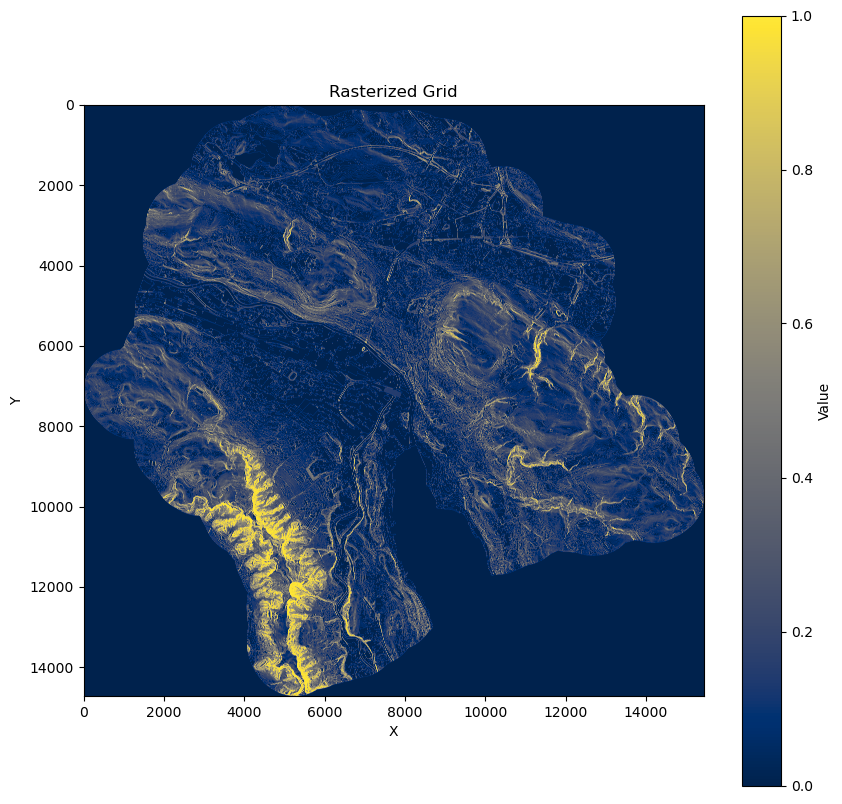

In [11]:
import matplotlib.pyplot as plt
import rasterio

# Read the raster data
with rasterio.open('raster.tif') as src:
    raster = src.read(1)

# Plot the raster data
plt.figure(figsize=(10, 10))
plt.imshow(raster, cmap='cividis')
plt.colorbar(label='Value')
plt.title('Rasterized Grid')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [11]:
with fiona.Env(SHAPE_RESTORE_SHX='YES'):
    # Load the shapefile
    foot_bike = gpd.read_file('./data/taz_mm.tbl_routennetz.shp')

foot_bike.head()

,geometry
0,"LINESTRING (2681451.647 1247734.633, 2681472.3..."
1,"LINESTRING (2681541.673 1247432.937, 2681532.0..."
2,"LINESTRING (2681499.585 1247605.517, 2681464.1..."
3,"LINESTRING (2681527.668 1247345.824, 2681524.9..."
4,"LINESTRING (2681552.300 1247147.539, 2681512.6..."


In [24]:
foot_paths_buffered = foot_bike.buffer(100)

0        POLYGON ((2681498.227 1247825.678, 2681507.570...
1        POLYGON ((2681476.353 1247356.330, 2681468.477...
2        POLYGON ((2681388.493 1247581.091, 2681382.445...
3        POLYGON ((2681434.090 1247309.973, 2681430.435...
4        POLYGON ((2681589.669 1247041.660, 2681573.599...
                               ...                        
40460    POLYGON ((2682789.387 1244632.945, 2682789.671...
40461    POLYGON ((2682424.634 1244457.797, 2682416.316...
40462    POLYGON ((2682624.617 1244548.347, 2682616.732...
40463    POLYGON ((2682245.285 1244471.413, 2682235.804...
40464    POLYGON ((2682608.247 1244382.589, 2682611.324...
Length: 40465, dtype: geometry

In [27]:
with rasterio.open('raster.tif') as src:
    out_image, out_transform = mask(src, foot_paths_buffered.geometry, crop=True)
    out_meta = src.meta.copy()

In [28]:
out_meta.update({
    "driver": "GTiff",
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

In [29]:
with rasterio.open('clipped_raster.tif', 'w', **out_meta) as dst:
    dst.write(out_image)

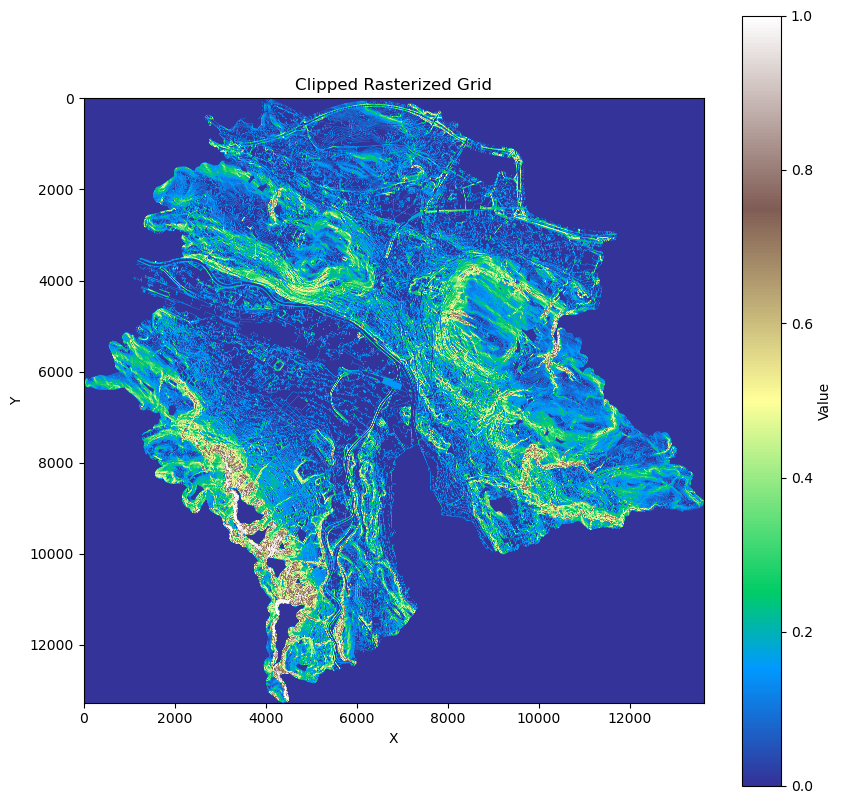

In [37]:
# Read the clipped raster data
with rasterio.open('clipped_raster.tif') as src:
    clipped_raster = src.read(1)

# Plot the clipped raster data
plt.figure(figsize=(10, 10))
plt.imshow(clipped_raster, cmap='terrain')
plt.colorbar(label='Value')
plt.title('Clipped Rasterized Grid')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

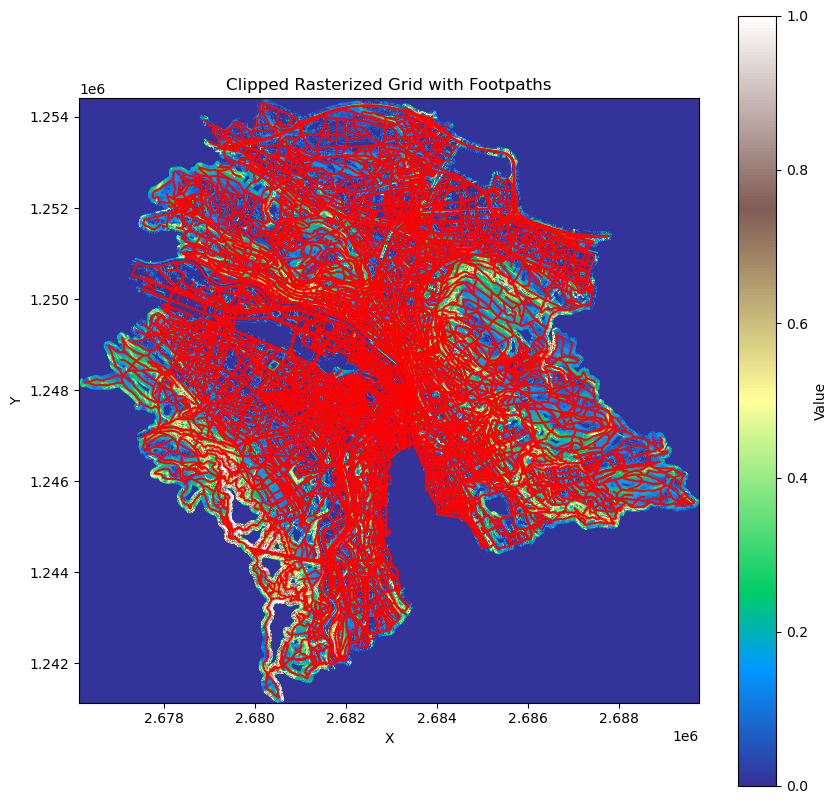

In [34]:
import matplotlib.pyplot as plt
import rasterio
import rasterio.plot
import geopandas as gpd

# Read the clipped raster data
with rasterio.open('clipped_raster.tif') as src:
    clipped_raster = src.read(1)
    raster_transform = src.transform

# Load the footpaths shapefile
footpaths = gpd.read_file('./data/taz_mm.tbl_routennetz.shp')

# Plot the clipped raster data
plt.figure(figsize=(10, 10))
plt.imshow(clipped_raster, cmap='terrain', extent=rasterio.plot.plotting_extent(src))
plt.colorbar(label='Value')
plt.title('Clipped Rasterized Grid with Footpaths')
plt.xlabel('X')
plt.ylabel('Y')

# Plot the footpaths
footpaths.plot(ax=plt.gca(), edgecolor='red')

plt.show()